
#**Machine Failure Prediction Using Machine Learning**
---
- Shreyas S D - 1AM23CI142
- Shashank B - 1AM23CI138
- Syed Taha - 1AM23CI163
- V Nageshwar - 1AM23CI175
- Shadin Muhammed - 1AM23CI136

##STEP 1 - Loading & Understanding Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d stephanmatzka/predictive-maintenance-dataset-ai4i-2020

Dataset URL: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
License(s): CC-BY-NC-SA-4.0
100% 136k/136k [00:00<00:00, 89.8MB/s]



In [ ]:
!unzip -o predictive-maintenance-dataset-ai4i-2020.zip

Archive:  predictive-maintenance-dataset-ai4i-2020.zip
  inflating: ai4i2020.csv            


In [ ]:
import pandas as pd
df = pd.read_csv('/content/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


##STEP 2 - Dataset Understanding

In [ ]:
#Check dataset size
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 14


In [ ]:
#View column names
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [ ]:
#Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
#Statistical summary
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
#Check missing values
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [ ]:
#Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
#Check unique values
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:10])


UDI:
[ 1  2  3  4  5  6  7  8  9 10]

Product ID:
['M14860' 'L47181' 'L47182' 'L47183' 'L47184' 'M14865' 'L47186' 'L47187'
 'M14868' 'M14869']

Type:
['M' 'L' 'H']

Air temperature [K]:
[298.1 298.2 298.3 298.5 298.4 298.6 298.7 298.8 298.9 299. ]

Process temperature [K]:
[308.6 308.7 308.5 309.  308.9 309.1 309.2 309.3 309.4 309.5]

Rotational speed [rpm]:
[1551 1408 1498 1433 1425 1558 1527 1667 1741 1782]

Torque [Nm]:
[42.8 46.3 49.4 39.5 40.  41.9 42.4 40.2 28.6 28. ]

Tool wear [min]:
[ 0  3  5  7  9 11 14 16 18 21]

Machine failure:
[0 1]

TWF:
[0 1]

HDF:
[0 1]

PWF:
[0 1]

OSF:
[0 1]

RNF:
[0 1]


In [ ]:
#Check the target variable
print(df['Machine failure'].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


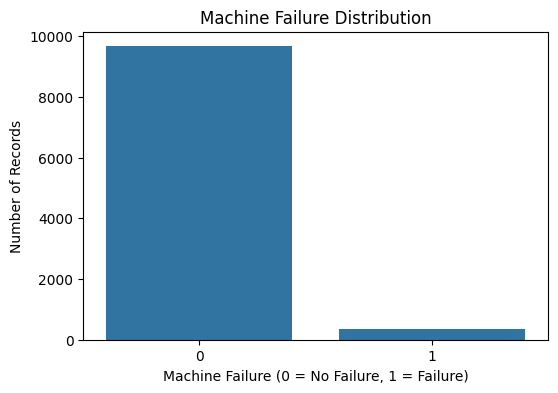

In [ ]:
#Target distribution graph
plt.figure(figsize=(6, 4))

sns.countplot(x='Machine failure', data=df)

plt.title('Machine Failure Distribution')
plt.xlabel('Machine Failure (0 = No Failure, 1 = Failure)')
plt.ylabel('Number of Records')

plt.show()

##STEP 3 - Data Peprocessing

In [ ]:
#Remove Irrelavant Columns
df = df.drop(['UDI', 'Product ID'], axis=1)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


In [ ]:
#Handle Type
print(df['Type'].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


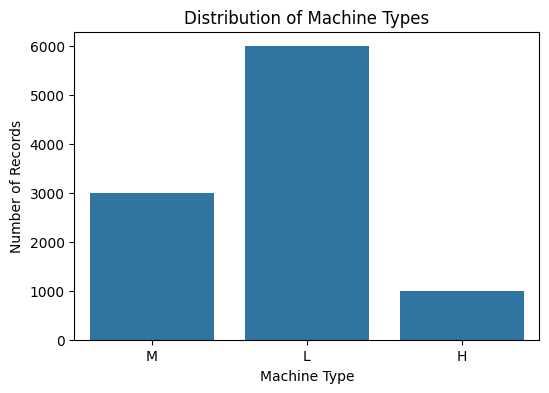

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Type', data=df)
plt.title('Distribution of Machine Types')
plt.xlabel('Machine Type')
plt.ylabel('Number of Records')
plt.show()

In [ ]:
#Encode Type
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


In [ ]:
#Remove Failure Indicator Columns
df = df.drop(['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [ ]:
print(df.columns)

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Type_L', 'Type_M'],
      dtype='object')


In [ ]:
#Separate Features and Target, Train-Test-Split & Scaling
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']
print("Features (X):")
print(X.columns)
print("\nTarget (y):")
print(y.name)
print("X shape:", X.shape)
print("y shape:", y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Features (X):
Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L',
       'Type_M'],
      dtype='object')

Target (y):
Machine failure
X shape: (10000, 7)
y shape: (10000,)
Training set: (8000, 7)
Testing set: (2000, 7)
Scaled training data shape: (8000, 7)
Scaled testing data shape: (2000, 7)


##STEP 4 - Exploratory Data Analysis

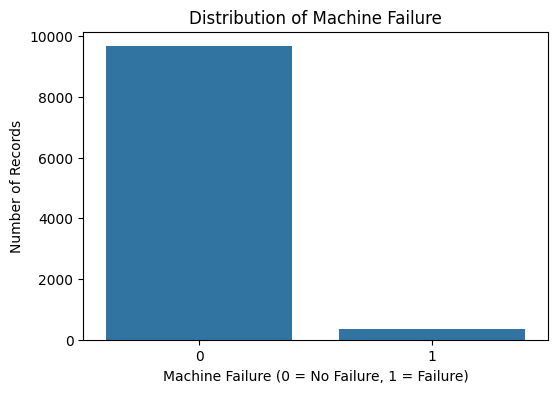

In [ ]:
#Machine Failure Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df)
plt.title('Distribution of Machine Failure')
plt.xlabel('Machine Failure (0 = No Failure, 1 = Failure)')
plt.ylabel('Number of Records')
plt.show()

In [ ]:
print(df['Machine failure'].value_counts())

print("\nPercentage Distribution:")
print(df['Machine failure'].value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64

Percentage Distribution:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


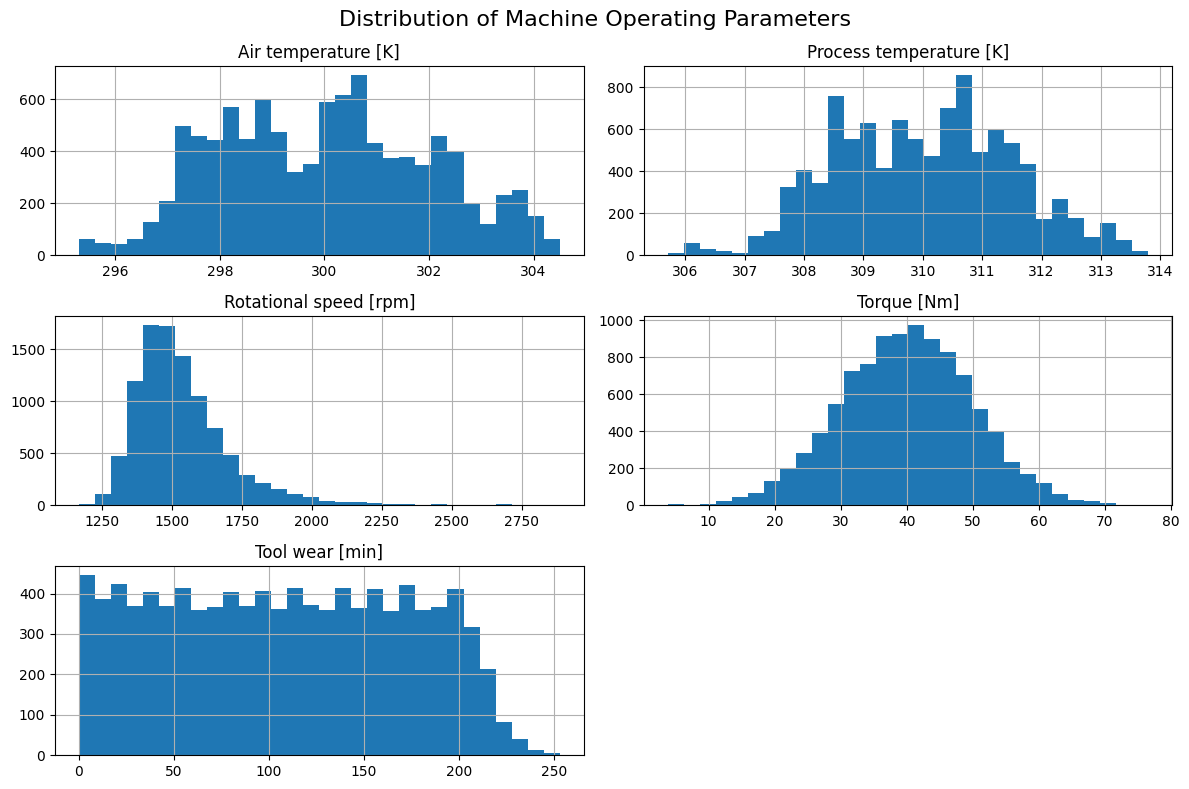

In [ ]:
#Feature Distribution Analysis
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
df[features].hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribution of Machine Operating Parameters', fontsize=16)
plt.tight_layout()
plt.show()

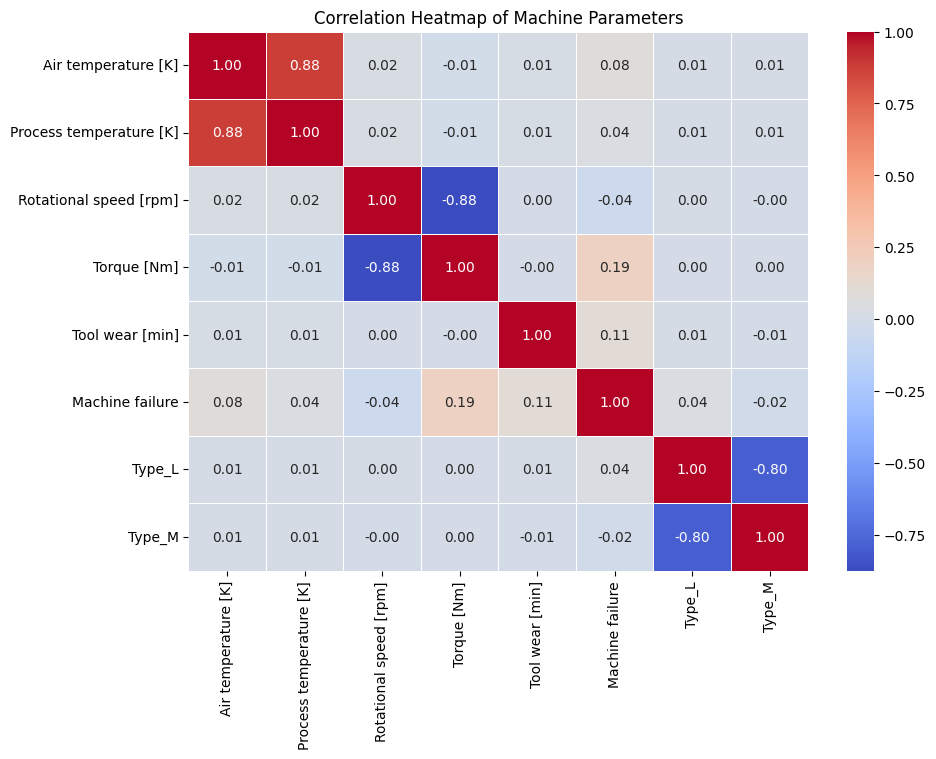

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10, 7))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Machine Parameters')
plt.show()

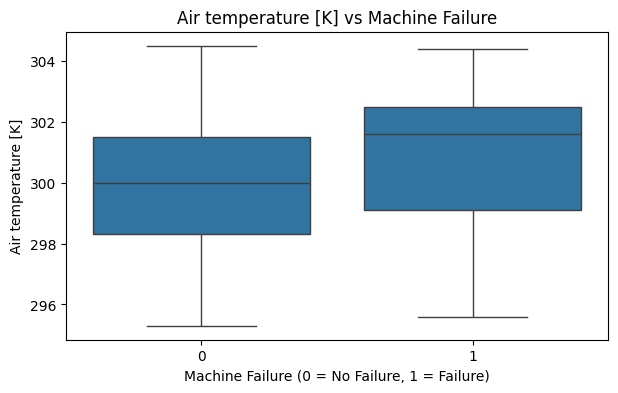

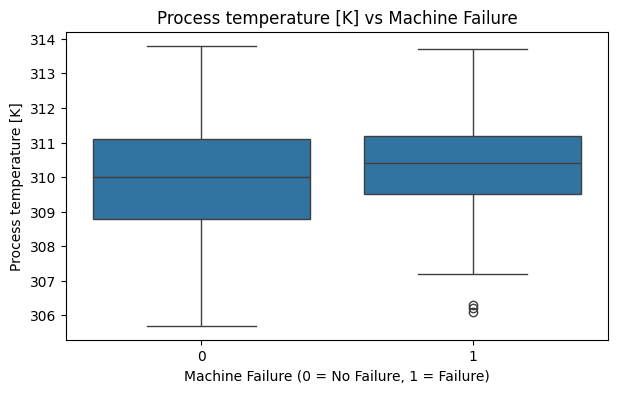

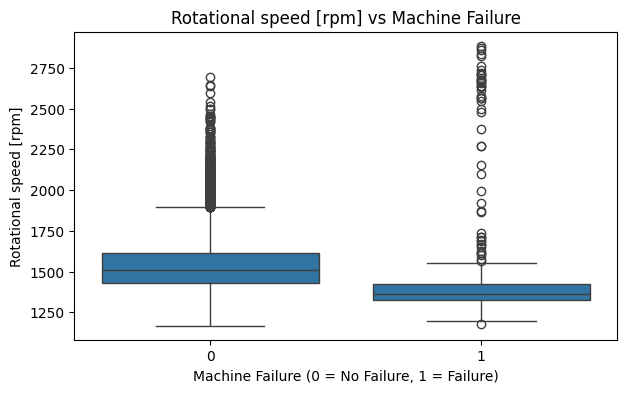

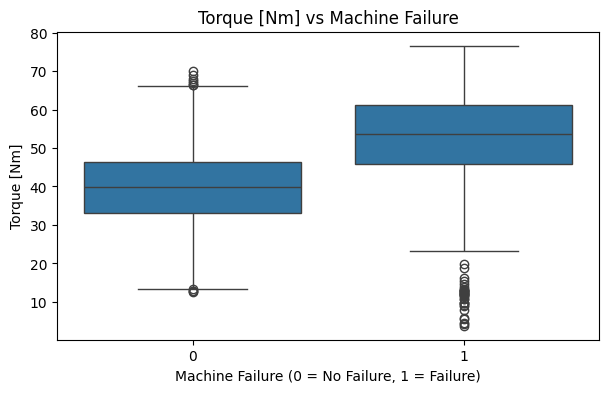

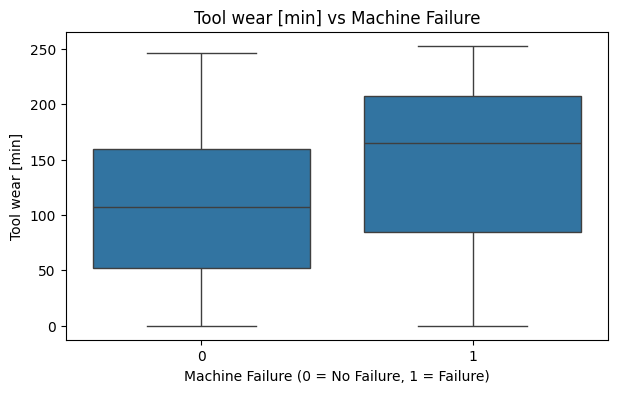

In [ ]:
#Analyze Features Against Machine Failure
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for feature in features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x='Machine failure',
        y=feature,
        data=df
    )

    plt.title(f'{feature} vs Machine Failure')
    plt.xlabel('Machine Failure (0 = No Failure, 1 = Failure)')
    plt.ylabel(feature)

    plt.show()

Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine failure, dtype: float64


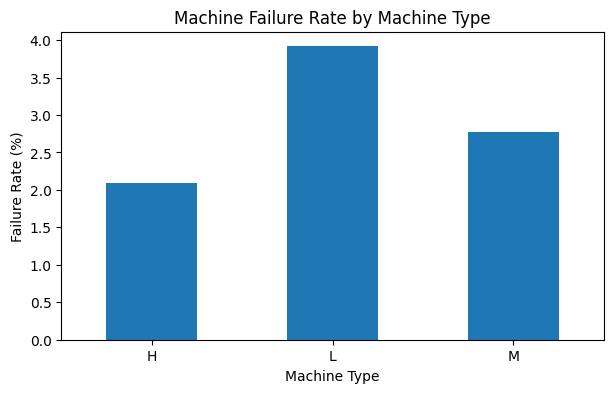

In [ ]:
#Failure Rate by Machine Type
original_df = pd.read_csv('/content/ai4i2020.csv')
failure_by_type = original_df.groupby('Type')['Machine failure'].mean() * 100
print(failure_by_type)
plt.figure(figsize=(7, 4))

failure_by_type.plot(kind='bar')

plt.title('Machine Failure Rate by Machine Type')
plt.xlabel('Machine Type')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=0)

plt.show()

#STEP 5 - Train the ML Models

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost

In [ ]:
#Creating Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
!pip install -q xgboost

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

dt_model = DecisionTreeClassifier(
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

gb_model = GradientBoostingClassifier(
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
#Training Models
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print("Logistic Regression training completed.")

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree training completed.")

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest training completed.")

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print("Gradient Boosting training completed.")

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = [
    'Air_Temperature',
    'Process_Temperature',
    'Rotational_Speed',
    'Torque',
    'Tool_Wear',
    'Type_L',
    'Type_M'
]

X_test_xgb.columns = X_train_xgb.columns

xgb_model.fit(X_train_xgb, y_train)
y_pred_xgb = xgb_model.predict(X_test_xgb)
print("XGBoost training completed.")

Logistic Regression training completed.
Decision Tree training completed.
Random Forest training completed.
Gradient Boosting training completed.
XGBoost training completed.


#STEP 6 - Evaluate The Models

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])


# Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])


# Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])


# Gradient Boosting
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:, 1])


# XGBoost
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test_xgb)[:, 1])

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy
    ],
    'Precision': [
        lr_precision,
        dt_precision,
        rf_precision,
        gb_precision,
        xgb_precision
    ],
    'Recall': [
        lr_recall,
        dt_recall,
        rf_recall,
        gb_recall,
        xgb_recall
    ],
    'F1 Score': [
        lr_f1,
        dt_f1,
        rf_f1,
        gb_f1,
        xgb_f1
    ],
    'ROC-AUC': [
        lr_auc,
        dt_auc,
        rf_auc,
        gb_auc,
        xgb_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9675,0.636364,0.102941,0.177215,0.899517
1,Decision Tree,0.9780,0.681818,0.661765,0.671642,0.825448
2,Random Forest,0.9815,0.878049,0.529412,0.660550,0.961599
3,Gradient Boosting,0.9860,0.884615,0.676471,0.766667,0.969770
4,XGBoost,0.9875,0.890909,0.720588,0.796748,0.972879


In [ ]:
results_display = results.copy()

for column in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    results_display[column] = results_display[column].map(lambda x: f"{x:.4f}")

results_display

results_display = results.copy()

for column in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    results_display[column] = results_display[column].map(lambda x: f"{x:.4f}")

results_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8995
1,Decision Tree,0.9780,0.6818,0.6618,0.6716,0.8254
2,Random Forest,0.9815,0.8780,0.5294,0.6606,0.9616
3,Gradient Boosting,0.9860,0.8846,0.6765,0.7667,0.9698
4,XGBoost,0.9875,0.8909,0.7206,0.7967,0.9729


In [ ]:
results_sorted = results.sort_values(
    by='F1 Score',
    ascending=False
)

results_sorted

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.9875,0.890909,0.720588,0.796748,0.972879
3,Gradient Boosting,0.9860,0.884615,0.676471,0.766667,0.969770
1,Decision Tree,0.9780,0.681818,0.661765,0.671642,0.825448
2,Random Forest,0.9815,0.878049,0.529412,0.660550,0.961599
0,Logistic Regression,0.9675,0.636364,0.102941,0.177215,0.899517


In [ ]:
results_sorted.style.format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1 Score': '{:.2%}',
    'ROC-AUC': '{:.2%}'
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,98.75%,89.09%,72.06%,79.67%,97.29%
3,Gradient Boosting,98.60%,88.46%,67.65%,76.67%,96.98%
1,Decision Tree,97.80%,68.18%,66.18%,67.16%,82.54%
2,Random Forest,98.15%,87.80%,52.94%,66.06%,96.16%
0,Logistic Regression,96.75%,63.64%,10.29%,17.72%,89.95%


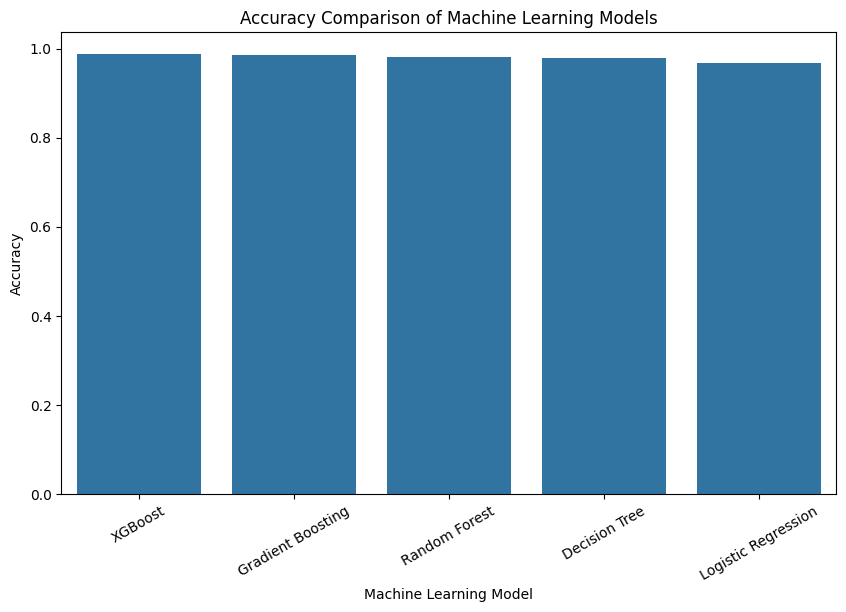

In [ ]:
#Accuracy Ciomparison Graph
results_sorted = results.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_sorted,
    x='Model',
    y='Accuracy'
)

plt.title('Accuracy Comparison of Machine Learning Models')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')

plt.xticks(rotation=30)

plt.show()

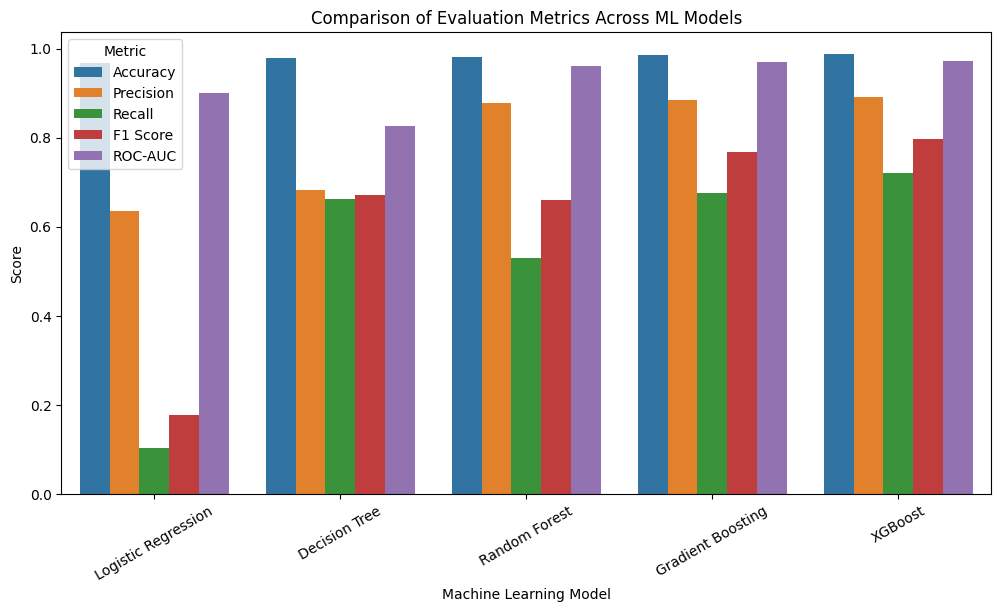

In [ ]:
#Compare All Evaluation Metrics
results_melted = results.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Comparison of Evaluation Metrics Across ML Models')
plt.xlabel('Machine Learning Model')
plt.ylabel('Score')

plt.xticks(rotation=30)

plt.show()

In [ ]:
best_model = results.loc[results['F1 Score'].idxmax()]
print("Best Performing Model:")
print(best_model)

print(
    f"\nThe best performing model is {best_model['Model']} "
    f"with an F1 Score of {best_model['F1 Score']:.2%}"
)

Best Performing Model:
Model         XGBoost
Accuracy       0.9875
Precision    0.890909
Recall       0.720588
F1 Score     0.796748
ROC-AUC      0.972879
Name: 4, dtype: object

The best performing model is XGBoost with an F1 Score of 79.67%


#STEP 7 - Classification Report for XGBoost + Confusion Matrix

In [ ]:
#Classification Report
from sklearn.metrics import classification_report
print("Classification Report - XGBoost")
print(classification_report(y_test, y_pred_xgb))

Classification Report - XGBoost
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.72      0.80        68

    accuracy                           0.99      2000
   macro avg       0.94      0.86      0.90      2000
weighted avg       0.99      0.99      0.99      2000




The classification report evaluates the performance of XGBoost for both machine failure classes. Precision, recall, and F1-score are considered particularly important because the dataset is highly imbalanced.

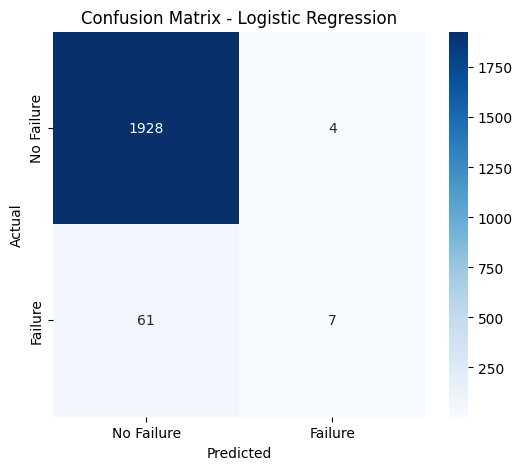

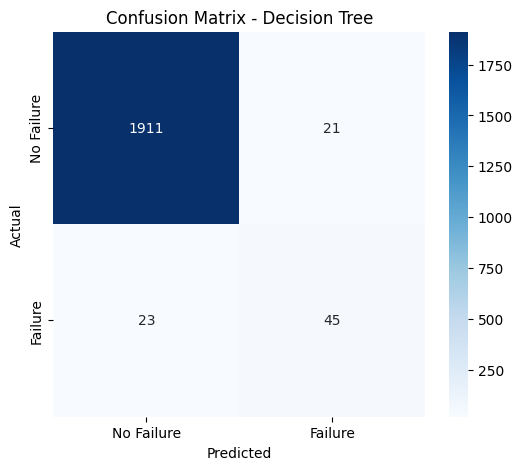

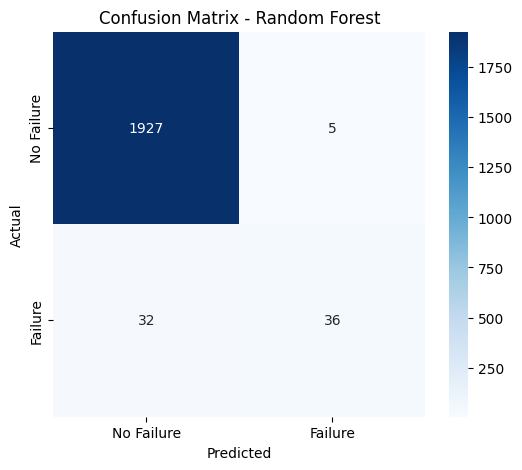

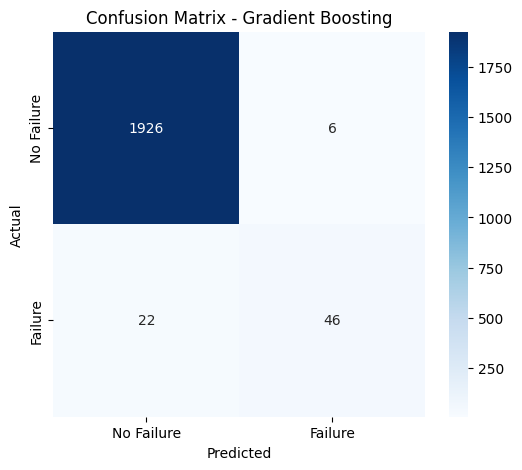

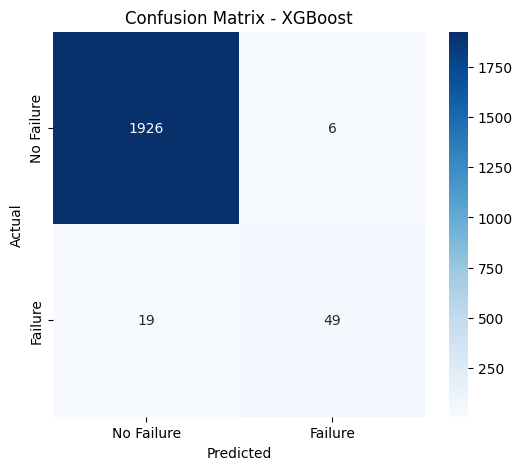

In [ ]:
#Confusion Matrix
for name, y_pred in models_preds:
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Failure', 'Failure'],
        yticklabels=['No Failure', 'Failure']
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f"cm_{name.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()



The confusion matrix shows the number of correctly and incorrectly classified instances. The rows represent the actual classes, while the columns represent the predicted classes.

For predictive maintenance, false negatives are particularly important because they represent actual machine failures that were not detected by the model.

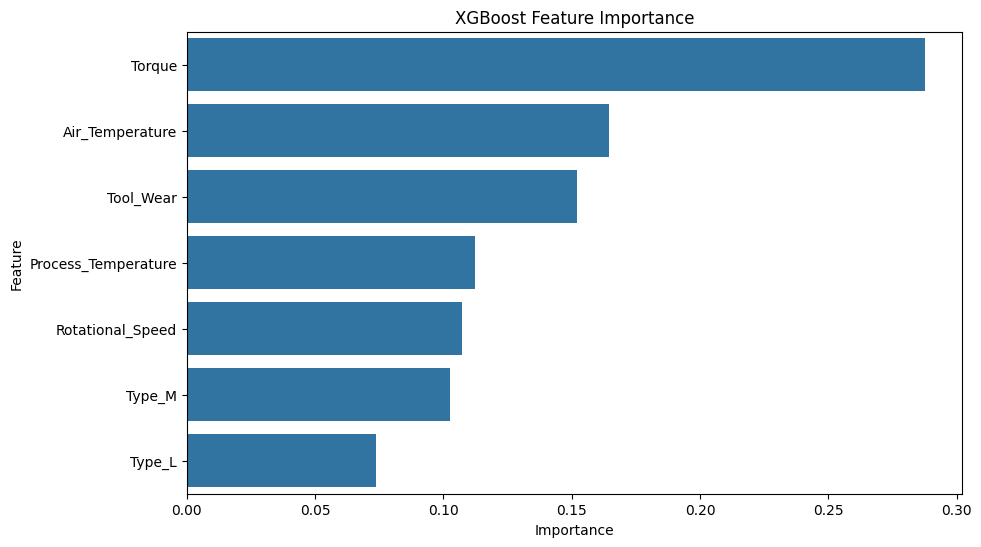

In [ ]:
#Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': xgb_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()



Feature importance analysis was performed to identify the machine parameters that contributed most to the XGBoost model's predictions. This helps in understanding which operating conditions have greater influence on machine failure prediction.

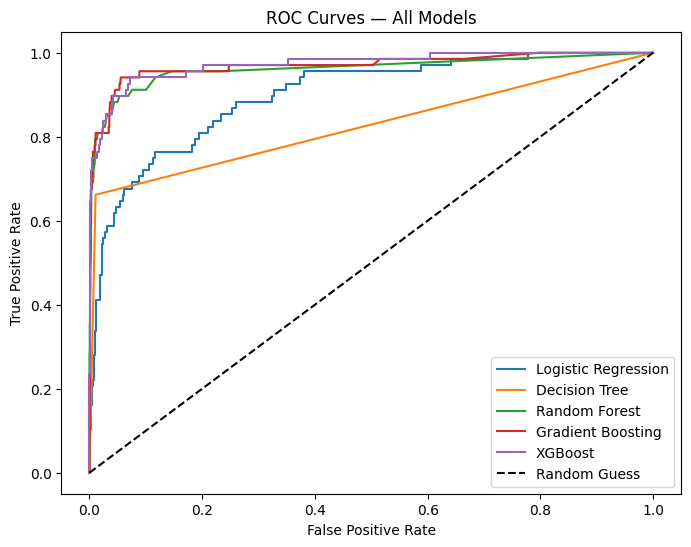

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, model, X_te in [
    ('Logistic Regression', lr_model, X_test_scaled),
    ('Decision Tree', dt_model, X_test),
    ('Random Forest', rf_model, X_test),
    ('Gradient Boosting', gb_model, X_test),
    ('XGBoost', xgb_model, X_test_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_te)[:, 1])
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.show()

#STEP 8 - Final Results & Discussion

### Model Comparison

| Rank | Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---:|---|---:|---:|---:|---:|---:|
| 1 | **XGBoost** | **98.75%** | **89.09%** | **72.06%** | **79.67%** | **97.29%** |
| 2 | Gradient Boosting | 98.60% | 88.46% | 67.65% | 76.67% | 96.98% |
| 3 | Random Forest | 98.15% | 87.80% | 52.94% | 66.06% | 96.16% |
| 4 | Decision Tree | 97.80% | 68.18% | 66.18% | 67.16% | 82.54% |
| 5 | Logistic Regression | 96.75% | 63.64% | 10.29% | 17.72% | 89.95% |



### Analysis

**XGBoost performed the best overall**, achieving the highest accuracy (98.75%), precision (89.09%), recall (72.06%), F1-score (79.67%), and ROC-AUC (97.29%).

**Gradient Boosting** was the second-best model, while **Random Forest** had lower recall (52.94%), meaning it missed more actual failures.

**Logistic Regression** had 96.75% accuracy but only **10.29% recall**, showing that accuracy alone is not sufficient for predictive maintenance.

### Why XGBoost Performed Best

XGBoost builds decision trees sequentially, where each new tree corrects errors from previous trees. This helps it capture **complex patterns in machine operating data**.

Therefore, **XGBoost was selected as the best model** for predicting machine failures.

#STEP 9 - Conclusion

In this project, five machine learning algorithms were applied to the AI4I 2020 Predictive Maintenance dataset to predict machine failures based on operating parameters such as air temperature, process temperature, rotational speed, torque, tool wear, and machine type.

The models evaluated were Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Their performance was compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Among the five algorithms, XGBoost achieved the best overall performance with an accuracy of 98.75%, precision of 89.09%, recall of 72.06%, F1-score of 79.67%, and ROC-AUC of 97.29%. The confusion matrix showed that the model correctly detected 49 of the 68 actual machine failure cases while producing only 6 false positive predictions.

Feature importance analysis indicated that Torque was the most influential feature, followed by Air Temperature and Tool Wear.

The results demonstrate that machine learning can be effectively used for predictive maintenance and early detection of potential machine failures. Based on the experimental comparison, XGBoost was identified as the most suitable model among the evaluated algorithms for this dataset.